# NSD predict

### data clean up
keeping only patient used for training and validation on best COMIND model

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"
time_col = "time"
cat_levels = [1, 2, 3, 4, 5]

# Keep full longitudinal panel by default.
df_all = pd.read_csv(data_path)

print(df_all["NSD_STAGE"].value_counts(dropna=True))

def build_ordinal_panel(df, feature_cols):
    panel_df = df.copy()

    if "time" in panel_df.columns:
        panel_df["time"] = pd.to_numeric(panel_df["time"], errors="coerce") / 12.0
    
    nsd_raw = panel_df["NSD_STAGE"].astype(str).str.strip().str.lower()
    # map text variants first
    panel_df.loc[nsd_raw.isin(["2a", "2b"]), "NSD_STAGE"] = 2
    #panel_df.loc[nsd_raw.isin(["not nsd", "not_nsd", "none", "nan", ""]), "NSD_STAGE"] = np.nan

    panel_df["NSD_STAGE"] = pd.to_numeric(panel_df["NSD_STAGE"], errors="coerce")
    panel_df.loc[panel_df["NSD_STAGE"] == 0, "NSD_STAGE"] = np.nan
    # Merge sparse top class: stage 6 -> stage 5
    panel_df.loc[panel_df["NSD_STAGE"] == 6, "NSD_STAGE"] = 5

    panel_df["NSD_ordered"] = pd.Categorical(
        panel_df["NSD_STAGE"], categories=cat_levels, ordered=True
    )

    # Only require columns needed for current model.
    cols_needed = ["NSD_ordered", "subj_id", "model_split_best"] + feature_cols
    model_df = panel_df[cols_needed].copy()

    # Force predictors numeric, then drop NaN/inf rows.
    model_df[feature_cols] = model_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_needed).copy()

    ord_train = model_df[model_df["model_split_best"] == "train"].copy()
    ord_val = model_df[model_df["model_split_best"] == "val"].copy()

    # Critical for OrderedModel stability: fit on observed train classes only.
    ord_train["NSD_ordered"] = pd.Categorical(
        ord_train["NSD_ordered"].astype(float), categories=cat_levels, ordered=True
    )
    ord_train["NSD_ordered"] = ord_train["NSD_ordered"].cat.remove_unused_categories()

    train_cats = ord_train["NSD_ordered"].cat.categories
    ord_val["NSD_ordered"] = pd.Categorical(
        ord_val["NSD_ordered"].astype(float), categories=train_cats, ordered=True
    )
    # Drop validation rows with classes not seen in train.
    ord_val = ord_val.dropna(subset=["NSD_ordered"]).copy()

    return model_df, ord_train, ord_val


base_features = ["MCATOT", "TD_score", "PIGD_score", "subtype_best", "beta_0", "beta_1", "beta_2", "time"]
model_df, ord_train, ord_val = build_ordinal_panel(df_all, base_features)
full_cats = pd.Index(cat_levels)

print("\nRows by model_split_best:")
print(df_all["model_split_best"].value_counts(dropna=False))
print("\nUnique subjects by model_split_best:")
print(df_all.groupby("model_split_best")["subj_id"].nunique())
print("\nLongitudinal complete cases for base model:")
print("Train n:", len(ord_train), "| Val n:", len(ord_val))
print("Train NSD counts:\n", ord_train["NSD_ordered"].value_counts().sort_index())
print("Val NSD counts:\n", ord_val["NSD_ordered"].value_counts().sort_index())

NSD_STAGE
3          527
4          133
2b         131
Not NSD     46
5            8
2a           1
6            1
Name: count, dtype: int64

Rows by model_split_best:
model_split_best
train       513
not_used    235
val         132
Name: count, dtype: int64

Unique subjects by model_split_best:
model_split_best
not_used    231
train       116
val          30
Name: subj_id, dtype: int64

Longitudinal complete cases for base model:
Train n: 470 | Val n: 125
Train NSD counts:
 NSD_ordered
2     69
3    309
4     86
5      6
Name: count, dtype: int64
Val NSD counts:
 NSD_ordered
2    20
3    73
4    29
5     3
Name: count, dtype: int64


In [16]:
# Check longitudinal monotonicity of NSD stage (allowing ties)

import numpy as np
import pandas as pd

def canonicalize_nsd(series):
    s = series.astype(str).str.strip().str.lower()
    out = series.copy()

    # map text labels first
    out.loc[s.isin(["2a", "2b"])] = 2
    out.loc[s.isin(["not nsd", "not_nsd", "none", "nan", ""])] = np.nan

    # numeric cleanup
    out = pd.to_numeric(out, errors="coerce")
    out.loc[out == 0] = np.nan
    out.loc[out == 6] = 5
    return out

chk = df_all.copy()
chk["time"] = pd.to_numeric(chk["time"], errors="coerce")
chk["NSD_clean"] = canonicalize_nsd(chk["NSD_STAGE"])

# keep rows where both time and stage exist
chk = chk.dropna(subset=["subj_id", "time", "NSD_clean"]).copy()

def subject_monotonicity(grp):
    g = grp.sort_values("time")
    v = g["NSD_clean"].to_numpy()
    d = np.diff(v)
    ok_nondecreasing = np.all(d >= 0)   # ties allowed
    ok_strict = np.all(d > 0)           # strictly increasing
    n_decreases = int(np.sum(d < 0))
    return pd.Series({
        "n_obs": len(v),
        "first_stage": v[0],
        "last_stage": v[-1],
        "nondecreasing_ok": ok_nondecreasing,
        "strictly_increasing_ok": ok_strict,
        "n_decreases": n_decreases
    })

mono = chk.groupby("subj_id", as_index=False).apply(subject_monotonicity).reset_index(drop=True)

print("Subjects with >=1 usable NSD point:", len(mono))
print("Nondecreasing subjects:", int(mono["nondecreasing_ok"].sum()))
print("Violators:", int((~mono["nondecreasing_ok"]).sum()))
print("Percent nondecreasing: %.1f%%" % (100 * mono["nondecreasing_ok"].mean()))

viol = mono.loc[~mono["nondecreasing_ok"], ["subj_id", "n_obs", "first_stage", "last_stage", "n_decreases"]]
print("\nExample violators (up to 20):")
print(viol.head(20).to_string(index=False))

# Optional: inspect one violating subject's trajectory
if len(viol) > 0:
    sid = viol.iloc[0]["subj_id"]
    traj = chk.loc[chk["subj_id"] == sid, ["subj_id", "time", "NSD_STAGE", "NSD_clean"]].sort_values("time")
    print(f"\nTrajectory for first violator subj_id={sid}:")
    print(traj.to_string(index=False))

Subjects with >=1 usable NSD point: 334
Nondecreasing subjects: 308
Violators: 26
Percent nondecreasing: 92.2%

Example violators (up to 20):
 subj_id  n_obs  first_stage  last_stage  n_decreases
    3107      7       2.0000      2.0000            1
    3134      5       2.0000      2.0000            1
    3154      6       3.0000      3.0000            1
    3179      5       3.0000      3.0000            1
    3308      5       3.0000      3.0000            1
    3327      5       2.0000      2.0000            1
    3352      5       3.0000      4.0000            1
    3367      4       4.0000      4.0000            1
    3374      3       3.0000      2.0000            1
    3392      4       4.0000      3.0000            1
    3556      4       3.0000      3.0000            1
    3557      7       4.0000      4.0000            2
    3575      7       4.0000      3.0000            1
    3588      6       4.0000      4.0000            2
    3591      4       2.0000      2.0000        

## Weighted Ordered Model

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel

class WeightedOrderedModel(OrderedModel):
    def __init__(self, endog, exog, sample_weights=None, distr="logit", **kwargs):
        super().__init__(endog, exog, distr=distr, **kwargs)
        if sample_weights is None:
            sample_weights = np.ones(self.nobs)
        w = np.asarray(sample_weights, dtype=float)
        self.sample_weights = w * (self.nobs / w.sum())

    def loglikeobs(self, params):
        return self.sample_weights * super().loglikeobs(params)

    def score_obs(self, params):
        return self.sample_weights[:, None] * super().score_obs(params)

In [18]:
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt

# Data
y_train = ord_train["NSD_ordered"].cat.remove_unused_categories()
X_train = ord_train[["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]].astype(float)
y_val   = ord_val["NSD_ordered"].cat.remove_unused_categories()
X_val   = ord_val[["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]].astype(float)

# y_train = ord_train["NSD_ordered"].cat.remove_unused_categories()
# X_train = ord_train[["MCATOT", "TD_score", "PIGD_score"]].astype(float)
# y_val   = ord_val["NSD_ordered"].cat.remove_unused_categories()
# X_val   = ord_val[["MCATOT", "TD_score", "PIGD_score"]].astype(float)

full_cats = y_train.cat.categories

# print("Train NSD counts:\n", y_train.value_counts().sort_index())
# print("Val NSD counts:\n",   y_val.value_counts().sort_index())

# Compute weights and fit
w_train = compute_sample_weight(class_weight="balanced", y=y_train)

mod = WeightedOrderedModel(y_train, X_train, sample_weights=w_train, distr="logit")
res = mod.fit(method="bfgs", disp=False, cov_type="HC1", maxiter=300)
print(res.summary())

# predict
def get_preds(res, X):
    probs   = res.model.predict(params=res.params, exog=X)
    idx     = np.argmax(probs, axis=1)
    pred    = pd.Series(full_cats[idx], index=X.index).astype(float)
    return probs, pred

probs_train, pred_train = get_preds(res, X_train)
probs_val,   pred_val   = get_preds(res, X_val)

true_train = y_train.astype(float)
true_val   = y_val.astype(float)

# ── Metrics ───────────────────────────────────────────────────────────────────
labs = full_cats.astype(float)

from sklearn.metrics import cohen_kappa_score, mean_absolute_error

print(f"\nTrain accuracy:      {accuracy_score(true_train, pred_train):.4f}")
print(f"Val   accuracy:      {accuracy_score(true_val,   pred_val):.4f}")
print(f"Train F1 macro:      {f1_score(true_train, pred_train, average='macro', labels=labs, zero_division=0):.4f}")
print(f"Val   F1 macro:      {f1_score(true_val,   pred_val,   average='macro', labels=labs, zero_division=0):.4f}")
print(f"Train MAE:           {mean_absolute_error(true_train, pred_train):.4f}")
print(f"Val   MAE:           {mean_absolute_error(true_val,   pred_val):.4f}")
print(f"Train weighted MAE:  {mean_absolute_error(true_train, pred_train, sample_weight=compute_sample_weight('balanced', true_train)):.4f}")
print(f"Val   weighted MAE:  {mean_absolute_error(true_val,   pred_val,   sample_weight=compute_sample_weight('balanced', true_val)):.4f}")
print(f"Train kappa:         {cohen_kappa_score(true_train, pred_train, weights='quadratic'):.4f}")
print(f"Val   kappa:         {cohen_kappa_score(true_val,   pred_val,   weights='quadratic'):.4f}")

# ── Probability diagnostics ───────────────────────────────────────────────────
print("\nAverage predicted probabilities by true stage (train):")
header = "  ".join([f"P(stage{int(c)})" for c in full_cats])
print(f"{'True stage':<12}  {header}  Most common pred")
for stage in full_cats.astype(float):
    mask = true_train == stage
    if mask.sum() == 0:
        continue
    avg = probs_train[mask.values].mean(axis=0)
    mc  = mode(full_cats[np.argmax(probs_train[mask.values], axis=1)])[0]
    probs_str = "      ".join([f"{v:.3f}" for v in avg])
    print(f"  Stage {stage:.0f}:      {probs_str}      {mc}")

print("\nThresholds:", res.params[len(["MCATOT","TD_score","PIGD_score"]):])

                          WeightedOrderedModel Results                          
Dep. Variable:              NSD_ordered   Log-Likelihood:                -496.03
Model:             WeightedOrderedModel   AIC:                             1010.
Method:              Maximum Likelihood   BIC:                             1047.
Date:                  Tue, 05 May 2026                                         
Time:                          11:36:54                                         
No. Observations:                   470                                         
Df Residuals:                       461                                         
Df Model:                             6                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
MCATOT        -0.4443      1.032     -0.430      0.667      -2.468       1.579
TD_score       0.0541      0.368  

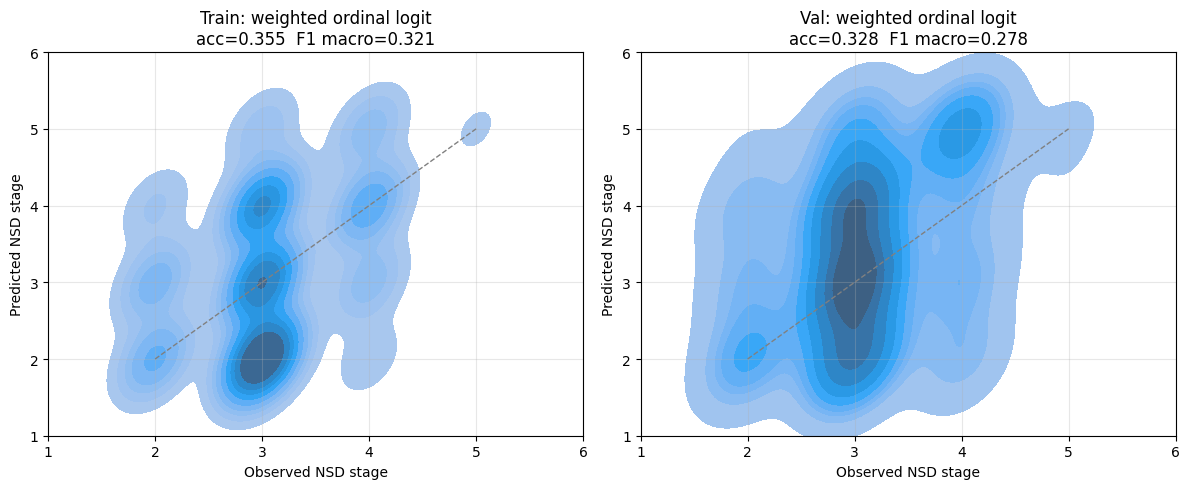

In [19]:
# KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, true, pred, title in [
    (axes[0], true_train, pred_train, "Train"),
    (axes[1], true_val,   pred_val,   "Val"),
]:
    sns.kdeplot(x=true, y=pred, fill=True, ax=ax)
    ax.plot([full_cats.min(), full_cats.max()],
            [full_cats.min(), full_cats.max()],
            ls="--", c="gray", lw=1, label="Perfect prediction")
    ax.set_xlabel("Observed NSD stage")
    ax.set_ylabel("Predicted NSD stage")
    acc = accuracy_score(true, pred)
    f1  = f1_score(true, pred, average="macro", labels=labs, zero_division=0)
    ax.set_title(f"{title}: weighted ordinal logit\nacc={acc:.3f}  F1 macro={f1:.3f}")
    ax.set_xlim(1, 6); ax.set_ylim(1, 6)
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("weighted_ordinal_kde.png", dpi=150, bbox_inches="tight")
plt.show()

### Alternative versions of weighted ordinal model

## Unweighted model with beta_subtypes
#### define model

In [20]:
# Longitudinal ordered logit with beta features (robust cleaning + diagnostics)
beta_features = ["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]
#beta_features = ["MCATOT", "TD_score", "PIGD_score"]
model_df_beta, ord_train_beta, ord_val_beta = build_ordinal_panel(df_all, beta_features)

X_train_beta = ord_train_beta[beta_features].copy()
y_train_beta = ord_train_beta["NSD_ordered"]

# Drop zero-variance predictors; they can break OrderedModel numerics.
std_train = X_train_beta.std(ddof=0)
constant_cols = std_train[std_train == 0].index.tolist()
if constant_cols:
    print("Dropping constant train columns:", constant_cols)
    beta_features_fit = [c for c in beta_features if c not in constant_cols]
else:
    beta_features_fit = beta_features

X_train_beta = ord_train_beta[beta_features_fit].astype(float)

# Ensure finite matrix and at least 2 classes.
bad_rows = ~np.isfinite(X_train_beta.to_numpy()).all(axis=1)
if bad_rows.any():
    print("Dropping non-finite train rows:", int(bad_rows.sum()))
    X_train_beta = X_train_beta.loc[~bad_rows].copy()
    y_train_beta = y_train_beta.loc[X_train_beta.index].copy()

print("Train rows:", len(X_train_beta))
print("Predictors used:", beta_features_fit)
print("Any NaN in X_train:", bool(X_train_beta.isna().any().any()))
print("Any inf in X_train:", bool(np.isinf(X_train_beta.to_numpy()).any()))
print("Train NSD counts:\n", y_train_beta.value_counts().sort_index())

if y_train_beta.nunique() < 2:
    raise ValueError("Need at least 2 NSD classes in training data after cleaning.")

mod_beta = OrderedModel(y_train_beta, X_train_beta, distr="logit")
res_beta = mod_beta.fit(
    method="bfgs",
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": ord_train_beta.loc[X_train_beta.index, "subj_id"]},
)

print(res_beta.summary())



Train rows: 470
Predictors used: ['MCATOT', 'TD_score', 'PIGD_score', 'beta_0', 'beta_1', 'beta_2']
Any NaN in X_train: False
Any inf in X_train: False
Train NSD counts:
 NSD_ordered
2     69
3    309
4     86
5      6
Name: count, dtype: int64
                             OrderedModel Results                             
Dep. Variable:            NSD_ordered   Log-Likelihood:                -376.65
Model:                   OrderedModel   AIC:                             771.3
Method:            Maximum Likelihood   BIC:                             808.7
Date:                Tue, 05 May 2026                                         
Time:                        11:36:56                                         
No. Observations:                 470                                         
Df Residuals:                     461                                         
Df Model:                           6                                         
                 coef    std err          z 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

# categories from the model's training target
full_cats = y_train_beta.cat.categories

# Build validation exog with exact fitted columns/order
X_val_beta = ord_val_beta[beta_features_fit].apply(pd.to_numeric, errors="coerce").astype(float)
y_val_beta = ord_val_beta["NSD_ordered"]

# optional finite-row filter for val
mask_val_finite = np.isfinite(X_val_beta.to_numpy()).all(axis=1)
X_val_beta = X_val_beta.loc[mask_val_finite].copy()
y_val_beta = y_val_beta.loc[mask_val_finite].copy()

# predict
pred_probas_train = res_beta.model.predict(params=res_beta.params, exog=X_train_beta)
pred_probas_val   = res_beta.model.predict(params=res_beta.params, exog=X_val_beta)

pred_idx_train = np.asarray(pred_probas_train).argmax(axis=1)
pred_idx_val   = np.asarray(pred_probas_val).argmax(axis=1)

pred_cat_train = pd.Series(full_cats[pred_idx_train], index=y_train_beta.index).astype(float)
pred_cat_val   = pd.Series(full_cats[pred_idx_val],   index=y_val_beta.index).astype(float)

true_cat_train = y_train_beta.astype(float)
true_cat_val   = y_val_beta.astype(float)

print(f"Train accuracy: {accuracy_score(true_cat_train, pred_cat_train):.4f}")
print(f"Val accuracy:   {accuracy_score(true_cat_val, pred_cat_val):.4f}")

print("F1 train (macro):", f1_score(true_cat_train, pred_cat_train, average="macro",
                                    labels=full_cats.astype(float), zero_division=0))
print("F1 val   (macro):", f1_score(true_cat_val, pred_cat_val, average="macro",
                                    labels=full_cats.astype(float), zero_division=0))
from sklearn.metrics import cohen_kappa_score, mean_absolute_error

# Weighted kappa — standard for ordinal agreement, penalizes 
# distant errors more than adjacent ones
kappa = cohen_kappa_score(true_cat_val, pred_cat_val, weights="quadratic")
print(f"Quadratic weighted kappa: {kappa:.3f}")

# Mean absolute error in stage units — directly interpretable
mae = mean_absolute_error(true_cat_val.astype(float), pred_cat_val.astype(float))
print(f"MAE (stage units): {mae:.3f}")

# Kendall tau — already have this, keep it
# Accuracy — keep it but note the naive baseline
naive_acc = (true_cat_val == true_cat_val.mode()[0]).mean()
print(f"Naive baseline acc (predict majority): {naive_acc:.3f}")


Train accuracy: 0.6872
Val accuracy:   0.6480
F1 train (macro): 0.30563922356091033
F1 val   (macro): 0.3194616977225673
Quadratic weighted kappa: 0.395
MAE (stage units): 0.360
Naive baseline acc (predict majority): 0.584


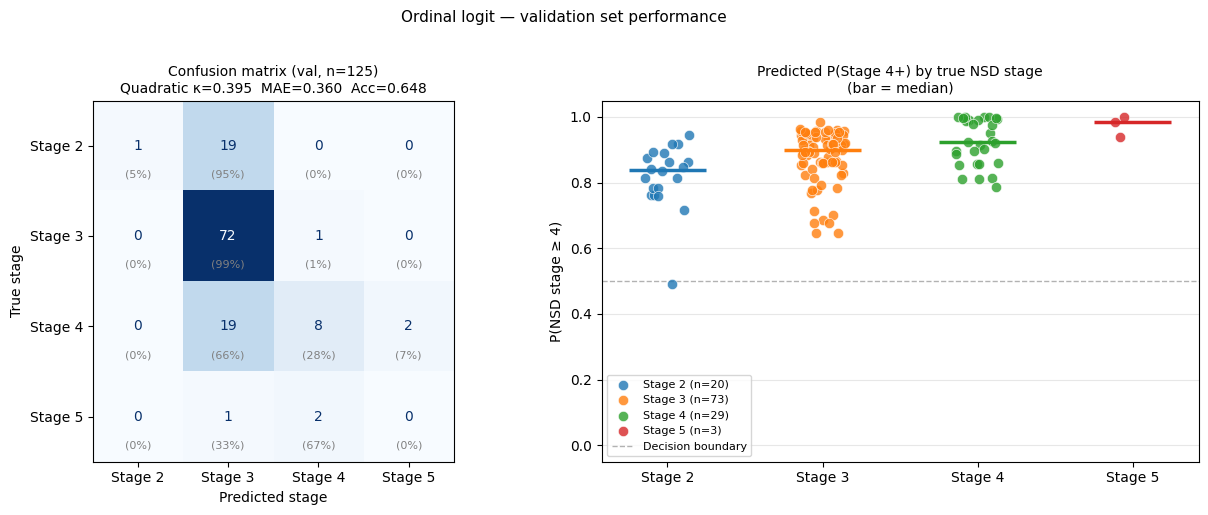

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tab10 = plt.cm.tab10.colors
stages = [2, 3, 4, 5]   # val only has 3 stages
stage_colors = {2: tab10[0], 3: tab10[1], 4: tab10[2], 5: tab10[3]}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Confusion matrix ─────────────────────────────────────────────────
ax = axes[0]
cm = confusion_matrix(true_cat_val.astype(int),
                       pred_cat_val.astype(int), labels=stages)
disp = ConfusionMatrixDisplay(cm, display_labels=[f"Stage {s}" for s in stages])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

# Annotate with row-normalized % below the count
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
for i in range(len(stages)):
    for j in range(len(stages)):
        ax.text(j, i + 0.32, f"({cm_norm[i,j]:.0%})",
                ha="center", va="center", fontsize=8, color="gray")

ax.set_title(f"Confusion matrix (val, n={len(true_cat_val)})\n"
             f"Quadratic κ={kappa:.3f}  MAE={mae:.3f}  Acc={accuracy_score(true_cat_val, pred_cat_val):.3f}",
             fontsize=10)
ax.set_xlabel("Predicted stage"); ax.set_ylabel("True stage")

# ── Panel 2: Predicted P(stage 4+) by true stage ─────────────────────────────
# More informative than raw predictions — shows model confidence
ax = axes[1]

# P(stage 4+) = sum of predicted probs for stages 4, 5, 6
stage4plus_prob = pred_probas_val[:, 1:].sum(axis=1)  # cols: stage3, stage4, stage5(+6)

plot_df = pd.DataFrame({
    "true_stage": true_cat_val.values.astype(int),
    "p_stage4plus": stage4plus_prob,
}).reset_index(drop=True)

# Jitter x so points don't overlap
rng = np.random.RandomState(42)
for stage in stages:
    mask = plot_df["true_stage"] == stage
    n = mask.sum()
    x_jitter = stage + rng.uniform(-0.15, 0.15, n)
    ax.scatter(x_jitter, plot_df.loc[mask, "p_stage4plus"],
               color=stage_colors[stage], s=55, alpha=0.8,
               edgecolors="white", linewidths=0.5,
               label=f"Stage {stage} (n={n})", zorder=3)
    # Median line
    med = plot_df.loc[mask, "p_stage4plus"].median()
    ax.hlines(med, stage - 0.25, stage + 0.25,
              color=stage_colors[stage], linewidth=2.5, zorder=4)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6,
           label="Decision boundary")
ax.set_xticks(stages)
ax.set_xticklabels([f"Stage {s}" for s in stages])
ax.set_ylabel("P(NSD stage ≥ 4)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Predicted P(Stage 4+) by true NSD stage\n(bar = median)", fontsize=10)
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Ordinal logit — validation set performance", fontsize=11, y=1.02)
plt.tight_layout()
#plt.savefig("ordinal_val_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## ulimate BG model supreme

In [23]:
"""
Continuation-ratio / discrete-time survival ordinal regression for
longitudinal panel data, with sklearn-compatible API.
"""

from __future__ import annotations

import inspect
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.validation import check_is_fitted


class AdaBoostBinaryRegressor(BaseEstimator):
    """
    AdaBoost.R2 regressor wrapped to expose a binary-classifier-like
    predict_proba interface for use as a base hazard model.

    Fits an AdaBoostRegressor (Drucker 1997) on a {0, 1} target, treats
    the regression output as P(y=1 | x), and clips to (eps, 1-eps) to
    avoid degenerate logits during downstream calibration.

    Parameters mirror sklearn's AdaBoostRegressor; default loss='square'
    targets the conditional mean (a probability for 0/1 targets), unlike
    the package default 'linear' which targets the conditional median.
    """

    def __init__(
        self,
        estimator=None,
        n_estimators: int = 50,
        learning_rate: float = 1.0,
        loss: str = "square",
        random_state=None,
        eps: float = 1e-6,
    ):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.loss = loss
        self.random_state = random_state
        self.eps = eps

    def fit(self, X, y, sample_weight=None):
        y = np.asarray(y).astype(float)
        unique = np.unique(y)
        if not set(unique.tolist()).issubset({0.0, 1.0}):
            raise ValueError(
                f"AdaBoostBinaryRegressor expects binary {{0, 1}} targets; got {unique}"
            )
        self.regressor_ = AdaBoostRegressor(
            estimator=self.estimator,
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            loss=self.loss,
            random_state=self.random_state,
        )
        self.regressor_.fit(X, y, sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "regressor_")
        p1 = np.clip(self.regressor_.predict(X), self.eps, 1.0 - self.eps)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class OrdinalDiscreteTimeSurvival(BaseEstimator, ClassifierMixin):
    """
    Continuation-ratio / discrete-time survival ordinal classifier for
    longitudinal panel data.

    For an ordered target with classes c_1 < c_2 < ... < c_K, fits K-1
    independent binary "hazard" models, one per threshold. For threshold
    k (separating c_k from c_{k+1}), the model estimates

        h_k(j; x) = P(Y_{i,j} >= c_{k+1} | not-yet-crossed, x_{i,j})

    on the at-risk subset (subjects who have not yet crossed k) at each
    visit j. Subjects are right-censored at their last observed visit if
    they never cross.

    At prediction time, hazards are accumulated within subject in time
    order to give monotone (in visit) cumulative threshold-crossing
    probabilities

        F_k(j) = 1 - prod_{j' <= j} (1 - h_k(j'; x_{j'}))

    from which per-class probabilities at each visit are derived via the
    continuation-ratio identity.

    Parameters
    ----------
    order : array-like, optional
        Expected ordered class values, lowest to highest. REQUIRED if y
        is non-numeric. If y is numeric and `order` is None, classes are
        taken as np.unique(y) sorted ascending. Raises if y contains any
        value not in `order`.

    base_estimator : sklearn classifier, optional
        Binary classifier with `predict_proba`. One clone is fitted per
        threshold. Default: AdaBoostBinaryRegressor (AdaBoost.R2 with
        square loss, wrapped to expose predict_proba).

    subj_id_col, time_col : str
        Names of the subject-id and within-subject relative-time columns
        in X. Time values are used only to ORDER visits within a subject;
        their numeric values are not used as covariates.

    include_visit_index : bool, default=True
        Include the within-subject visit number (1, 2, ...) as a feature
        of each hazard model — represents the discrete-time baseline
        hazard.

    class_weight : {'balanced', None}, default='balanced'
        If 'balanced', applies inverse-frequency sample weights to each
        threshold's binary problem (computed within that threshold's
        at-risk set).

    enforce_threshold_ordering : bool, default=True
        At prediction time, enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2})
        by post-hoc cumulative max from the highest threshold downward.
        Without this, threshold-specific (non-PO) hazards may produce
        internally inconsistent stage probabilities.

    calibrate : bool, default=True
        Apply a per-threshold prior correction at predict time to undo
        the intercept shift introduced by class_weight='balanced'. Stores
        the true crossing rate pi_k on the at-risk set at fit time and
        subtracts log((1 - pi_k) / pi_k) from the predicted hazard logit.
        Only active when class_weight='balanced' was used at fit time.
        EXACT for logistic regression (intercept-only shift); APPROXIMATE
        for nonlinear base estimators (AdaBoost, gradient boosting, RF) —
        for those, held-out isotonic/Platt calibration is more principled.

    Attributes
    ----------
    classes_ : np.ndarray, shape (K,)
        Ordered class labels (output order of `predict_proba`).
    threshold_models_ : dict[int, estimator or tuple]
        Fitted estimator for threshold k, or a ('constant', value) pair
        if the at-risk set was degenerate (single class or empty).
    feature_names_ : list[str]
        Feature columns used by the hazard models, in order.
    K_ : int
        Number of classes.

    Notes
    -----
    Population-averaged model — does not estimate subject random effects.
    Cross-validate by SUBJECT (not by row) to avoid leakage.

    Per-visit reversals (Y going down then up due to noise) are handled
    by training on the FIRST-CROSSING time per (subject, threshold). Strict
    within-subject monotonicity is not required of the input, but the
    discrete-time survival interpretation assumes the underlying process
    is approximately monotone.
    """

    def __init__(
        self,
        order: Optional[Sequence] = None,
        base_estimator=None,
        subj_id_col: str = "subj_id",
        time_col: str = "time",
        include_visit_index: bool = True,
        class_weight: Optional[str] = "balanced",
        enforce_threshold_ordering: bool = True,
        calibrate: bool = True,
    ):
        self.order = order
        self.base_estimator = base_estimator
        self.subj_id_col = subj_id_col
        self.time_col = time_col
        self.include_visit_index = include_visit_index
        self.class_weight = class_weight
        self.enforce_threshold_ordering = enforce_threshold_ordering
        self.calibrate = calibrate

    # ---------------- internal helpers ----------------

    def _validate_classes(self, y: np.ndarray) -> np.ndarray:
        observed = pd.unique(y)
        if self.order is None:
            if not np.issubdtype(np.asarray(y).dtype, np.number):
                raise ValueError(
                    f"y has non-numeric dtype {np.asarray(y).dtype}; "
                    "non-numeric targets require an explicit `order=` argument."
                )
            return np.sort(observed)

        order_arr = np.asarray(self.order)
        if len(set(order_arr.tolist())) != len(order_arr):
            raise ValueError("`order` contains duplicate values.")
        extras = pd.Index(observed).difference(pd.Index(order_arr)).tolist()
        if extras:
            raise ValueError(
                f"y contains values not in `order`: {extras}. "
                f"Provided order: {list(order_arr)}"
            )
        return order_arr

    def _split_panel(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "X must be a pandas DataFrame containing "
                f"`{self.subj_id_col}` and `{self.time_col}` columns."
            )
        for col in (self.subj_id_col, self.time_col):
            if col not in X.columns:
                raise ValueError(f"Required column `{col}` missing from X.")
        subj = X[self.subj_id_col].to_numpy()
        time = X[self.time_col].to_numpy()
        feats = X.drop(columns=[self.subj_id_col, self.time_col])
        if y is None:
            return feats, subj, time
        y_arr = np.asarray(y)
        if len(y_arr) != len(X):
            raise ValueError(f"len(y) {len(y_arr)} != len(X) {len(X)}.")
        return feats, subj, time, y_arr

    @staticmethod
    def _within_subject_visit_index(subj_sorted: np.ndarray) -> np.ndarray:
        """1-indexed visit number within each subject, assuming input is
        already sorted by (subject, time)."""
        s = pd.Series(subj_sorted)
        return s.groupby(s, sort=False).cumcount().to_numpy() + 1

    @staticmethod
    def _sort_by_subject_time(subj: np.ndarray, time: np.ndarray) -> np.ndarray:
        # Stable sort: primary key subject, secondary key time.
        df = pd.DataFrame({"_s": subj, "_t": time})
        return df.sort_values(["_s", "_t"], kind="mergesort").index.to_numpy()

    # ---------------- fit ----------------

    def fit(self, X: pd.DataFrame, y):
        classes = self._validate_classes(np.asarray(y))
        self.classes_ = classes
        self.K_ = len(classes)
        if self.K_ < 2:
            raise ValueError(f"Need at least 2 classes; got {self.K_}.")
        rank_map = {c: i for i, c in enumerate(classes)}

        feats, subj, time, y_arr = self._split_panel(X, y)
        y_rank = np.array([rank_map[v] for v in y_arr], dtype=int)

        # Sort everything by (subject, time)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]
        y_rank_s = y_rank[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)
        self.feature_names_ = list(feats_s.columns)

        base = (
            self.base_estimator
            if self.base_estimator is not None
            else AdaBoostBinaryRegressor()
        )
        # Validate base estimator
        if not hasattr(base, "predict_proba"):
            raise TypeError(
                f"base_estimator {type(base).__name__} must implement predict_proba."
            )
        supports_sw = "sample_weight" in inspect.signature(base.fit).parameters

        df_subj = pd.Series(subj_s)
        Xv = feats_s.to_numpy()
        self.threshold_models_ = {}
        self.priors_ = {}  # pi_k = event rate on at-risk set, used for calibration

        for k in range(self.K_ - 1):
            crossed = (y_rank_s > k).astype(int)
            # Cumulative crossings within subject; "before this row" means
            # cumsum up to but not including this row.
            cs = pd.Series(crossed).groupby(df_subj, sort=False).cumsum().to_numpy()
            cs_before = cs - crossed
            at_risk = cs_before == 0  # not yet crossed coming into this visit

            if not at_risk.any():
                self.threshold_models_[k] = ("constant", 0.0)
                self.priors_[k] = 0.0
                continue

            X_k = Xv[at_risk]
            y_k = crossed[at_risk]
            self.priors_[k] = float(y_k.mean())

            if len(np.unique(y_k)) < 2:
                # Degenerate: all crossed (event=1) or none (event=0).
                self.threshold_models_[k] = ("constant", float(y_k.mean()))
                continue

            if self.class_weight == "balanced":
                sw = compute_sample_weight("balanced", y_k)
            elif self.class_weight is None:
                sw = None
            else:
                raise ValueError(
                    f"class_weight must be 'balanced' or None; got {self.class_weight!r}."
                )

            est = clone(base)
            if supports_sw:
                est.fit(X_k, y_k, sample_weight=sw)
            elif sw is not None:
                raise ValueError(
                    f"base_estimator {type(base).__name__} does not support "
                    "sample_weight; pass class_weight=None or use a different estimator."
                )
            else:
                est.fit(X_k, y_k)
            self.threshold_models_[k] = est

        return self

    # ---------------- predict ----------------

    def _cumulative_crossing_probs(self, X: pd.DataFrame) -> np.ndarray:
        """Per-row F_k(visit) = P(Y_{ij} >= c_{k+1} | x_{i,1:j}) for k=0..K-2."""
        check_is_fitted(self)
        feats, subj, time = self._split_panel(X)
        order_idx = self._sort_by_subject_time(subj, time)
        feats_s = feats.iloc[order_idx].reset_index(drop=True)
        subj_s = subj[order_idx]

        if self.include_visit_index:
            feats_s = feats_s.copy()
            feats_s["__visit_index__"] = self._within_subject_visit_index(subj_s)

        missing = [c for c in self.feature_names_ if c not in feats_s.columns]
        if missing:
            raise ValueError(f"Features missing in X: {missing}")
        feats_s = feats_s[self.feature_names_]

        n = len(feats_s)
        Km1 = self.K_ - 1
        Xv = feats_s.to_numpy()

        hazards = np.zeros((n, Km1))
        apply_correction = self.calibrate and self.class_weight == "balanced"
        for k in range(Km1):
            m = self.threshold_models_[k]
            if isinstance(m, tuple) and m[0] == "constant":
                hazards[:, k] = m[1]
            else:
                h = m.predict_proba(Xv)[:, 1]
                if apply_correction:
                    pi = self.priors_.get(k, 0.5)
                    if 0.0 < pi < 1.0:
                        # logit(h_cal) = logit(h_bal) + log(pi / (1-pi))
                        # since balanced training shifted intercept by log((1-pi)/pi).
                        h = np.clip(h, 1e-12, 1 - 1e-12)
                        logit_h = np.log(h / (1.0 - h))
                        logit_h_cal = logit_h + np.log(pi / (1.0 - pi))
                        h = 1.0 / (1.0 + np.exp(-logit_h_cal))
                hazards[:, k] = h

        # Cumulative threshold-crossing prob within subject:
        # F_k(j) = 1 - prod_{j'<=j} (1 - h_k(j')); compute via cumsum of log(1-h).
        log_surv = np.log(np.clip(1.0 - hazards, 1e-12, 1.0))
        cum = (
            pd.DataFrame(log_surv)
            .groupby(subj_s, sort=False)
            .cumsum()
            .to_numpy()
        )
        F = 1.0 - np.exp(cum)

        # Enforce P(Y >= c_{k+1}) >= P(Y >= c_{k+2}) (consistency across thresholds)
        if self.enforce_threshold_ordering and Km1 >= 2:
            for k in range(Km1 - 2, -1, -1):
                F[:, k] = np.maximum(F[:, k], F[:, k + 1])

        # Restore original input row order
        unsort = np.argsort(order_idx)
        return F[unsort]

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """
        P(Y_{i,j} = c_m | history up to visit j) for each row of X.

        Returns array of shape (n_rows, K) with columns in `self.classes_` order.
        Within-subject sequences are monotone in the cumulative sense
        (F_k(j) non-decreasing in j) by construction.
        """
        F = self._cumulative_crossing_probs(X)  # (n, K-1); F[:, k] = P(Y >= c_{k+1})
        n, Km1 = F.shape
        K = Km1 + 1
        proba = np.empty((n, K))
        proba[:, 0] = 1.0 - F[:, 0]
        for m in range(1, K - 1):
            proba[:, m] = F[:, m - 1] - F[:, m]
        proba[:, K - 1] = F[:, K - 2]
        # Numerical safety
        proba = np.clip(proba, 0.0, None)
        s = proba.sum(axis=1, keepdims=True)
        s[s == 0] = 1.0
        return proba / s

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Modal stage prediction per row (label drawn from `self.classes_`)."""
        idx = np.argmax(self.predict_proba(X), axis=1)
        return np.asarray(self.classes_)[idx]


Order: [2. 3. 4. 5.]
Train NSD counts: {np.float64(2.0): np.int64(69), np.float64(3.0): np.int64(309), np.float64(4.0): np.int64(86), np.float64(5.0): np.int64(6)}
Val NSD counts: {np.float64(2.0): np.int64(20), np.float64(3.0): np.int64(73), np.float64(4.0): np.int64(29), np.float64(5.0): np.int64(3)}

Train accuracy:    0.6894
Val   accuracy:      0.5840
Train F1 macro:      0.4122
Val   F1 macro:      0.3240
Train MAE:           0.3170
Val   MAE:           0.4960
Train weighted MAE:  0.6612
Val   weighted MAE:  0.7043
Train kappa:         0.4219
Val   kappa:         0.3368


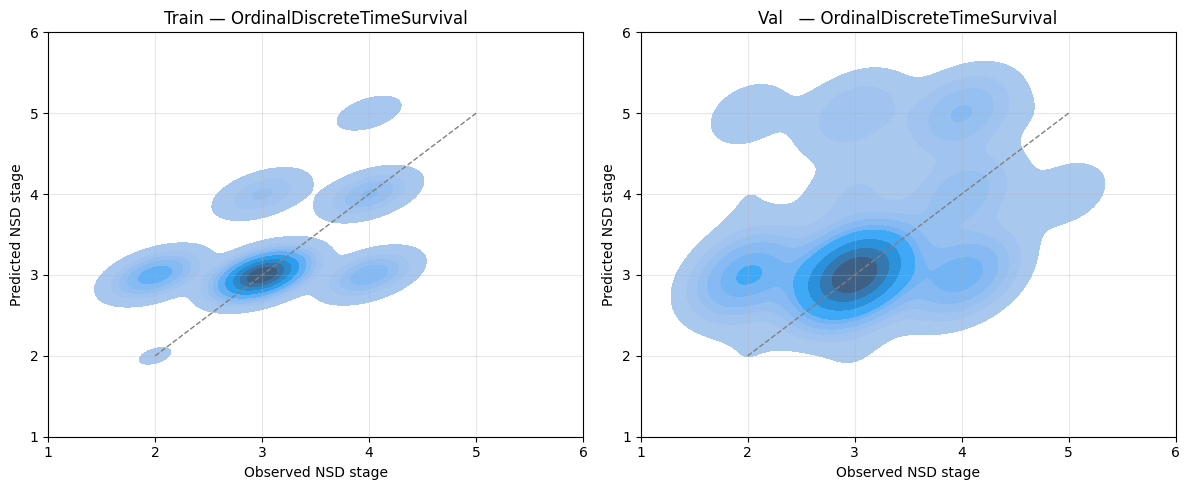

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import AdaBoostClassifier

#feature_cols = ["MCATOT", "TD_score", "PIGD_score"]
feature_cols = ["MCATOT", "TD_score", "PIGD_score", "beta_0", "beta_1", "beta_2"]

# X needs subj_id and time for the survival model to track visits
X_train = ord_train[["subj_id", "time"] + feature_cols].copy()
y_train = ord_train["NSD_ordered"].astype(float).to_numpy()
X_val   = ord_val[["subj_id", "time"] + feature_cols].copy()
y_val   = ord_val["NSD_ordered"].astype(float).to_numpy()

order = np.sort(np.unique(y_train))
print("Order:", order)
print("Train NSD counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val NSD counts:",   dict(zip(*np.unique(y_val,   return_counts=True))))

# ── Fit ───────────────────────────────────────────────────────────────────────
cr_model = OrdinalDiscreteTimeSurvival(
    order=order,
    # base_estimator=AdaBoostBinaryRegressor(n_estimators=100, random_state=0),
    base_estimator=LogisticRegression(max_iter=1000, random_state=0),
    subj_id_col="subj_id",
    time_col="time",
    include_visit_index=True,
    class_weight="balanced",
    enforce_threshold_ordering=True,

)
cr_model.fit(X_train, y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
pred_train = cr_model.predict(X_train)
pred_val   = cr_model.predict(X_val)
labs       = order

# ── Metrics ───────────────────────────────────────────────────────────────────
print(f"\nTrain accuracy:    {accuracy_score(y_train, pred_train):.4f}")
print(f"Val   accuracy:      {accuracy_score(y_val,   pred_val):.4f}")
print(f"Train F1 macro:      {f1_score(y_train, pred_train, average='macro', labels=labs, zero_division=0):.4f}")
print(f"Val   F1 macro:      {f1_score(y_val,   pred_val,   average='macro', labels=labs, zero_division=0):.4f}")
print(f"Train MAE:           {mean_absolute_error(y_train, pred_train):.4f}")
print(f"Val   MAE:           {mean_absolute_error(y_val,   pred_val):.4f}")
print(f"Train weighted MAE:  {mean_absolute_error(y_train, pred_train, sample_weight=compute_sample_weight('balanced', y_train)):.4f}")
print(f"Val   weighted MAE:  {mean_absolute_error(y_val,   pred_val,   sample_weight=compute_sample_weight('balanced', y_val)):.4f}")
print(f"Train kappa:         {cohen_kappa_score(y_train, pred_train, weights='quadratic'):.4f}")
print(f"Val   kappa:         {cohen_kappa_score(y_val,   pred_val,   weights='quadratic'):.4f}")

# ── KDE plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in [
    (axes[0], y_train, pred_train, "Train — OrdinalDiscreteTimeSurvival"),
    (axes[1], y_val,   pred_val,   "Val   — OrdinalDiscreteTimeSurvival"),
]:
    sns.kdeplot(x=true.astype(float), y=pred.astype(float), fill=True, ax=ax)
    lo, hi = float(order.min()), float(order.max())
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1)
    ax.set_xlabel("Observed NSD stage")
    ax.set_ylabel("Predicted NSD stage")
    ax.set_xlim(1,6)
    ax.set_ylim(1,6)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ordinal_survival_kde.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# GradientBoostBinaryClassifier — drop-in replacement for
# AdaBoostBinaryRegressor in OrdinalDiscreteTimeSurvival
#
# Uses HistGradientBoostingClassifier which:
#   - natively supports sample_weight
#   - supports early stopping via validation fraction
#   - is faster and more regularized than classic GBT
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted
import numpy as np


class GradientBoostBinaryClassifier(BaseEstimator):
    """
    HistGradientBoostingClassifier wrapped to match the
    AdaBoostBinaryRegressor interface used by OrdinalDiscreteTimeSurvival.

    Each threshold k in the continuation-ratio model gets its own clone
    of this estimator, fitted on the at-risk subset for that threshold.

    Parameters
    ----------
    max_iter : int
        Number of boosting rounds (equivalent to n_estimators).
    learning_rate : float
        Shrinkage applied to each tree.
    max_leaf_nodes : int
        Max leaves per tree. Controls complexity. 
        Equiv. to max_depth ~ log2(max_leaf_nodes).
        31 ≈ depth-5, 15 ≈ depth-4, 7 ≈ depth-3.
    l2_regularization : float
        L2 penalty on leaf values. Helps with imbalanced/small at-risk sets.
    early_stopping : bool
        If True, uses 20% of training data as internal val set to stop early.
        Useful when at-risk sets shrink at higher thresholds.
    random_state : int or None
    """

    def __init__(
        self,
        max_iter: int = 100,
        learning_rate: float = 0.1,
        max_leaf_nodes: int = 31,
        l2_regularization: float = 0.0,
        early_stopping: bool = False,
        random_state=None,
    ):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.max_leaf_nodes = max_leaf_nodes
        self.l2_regularization = l2_regularization
        self.early_stopping = early_stopping
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        y = np.asarray(y).astype(float)
        unique = np.unique(y)
        if not set(unique.tolist()).issubset({0.0, 1.0}):
            raise ValueError(
                f"GradientBoostBinaryClassifier expects binary {{0,1}} targets; "
                f"got {unique}"
            )
        # HistGBT requires int targets for classification
        self.clf_ = HistGradientBoostingClassifier(
            max_iter=self.max_iter,
            learning_rate=self.learning_rate,
            max_leaf_nodes=self.max_leaf_nodes,
            l2_regularization=self.l2_regularization,
            early_stopping=self.early_stopping,
            random_state=self.random_state,
            class_weight=None,  # we handle weighting via sample_weight
        )
        self.clf_.fit(X, y.astype(int), sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "clf_")
        return self.clf_.predict_proba(X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

## Ablation

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# ABLATION GRIDSEARCH: COMIND params vs clinical baseline
# Assumptions:
#   - subtype_proba_0/1/2 columns exist in ord_train / ord_val
#   - subj_id and time columns are present (carried over from build_ordinal_panel)
#   - WeightedOrderedModel and OrdinalDiscreteTimeSurvival defined in earlier cells
# ═══════════════════════════════════════════════════════════════════════════

import itertools
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import kendalltau

warnings.filterwarnings("ignore")

# ── 1. Feature Engineering ─────────────────────────────────────────────────

def add_model_features(df):
    """Add beta_assigned and subtype dummies. Preserves all existing columns."""
    df = df.copy()
    # Disease-time under the assigned subtype only
    df["beta_assigned"] = np.select(
        [df["subtype_best"] == 0, df["subtype_best"] == 1, df["subtype_best"] == 2],
        [df["beta_0"],            df["beta_1"],             df["beta_2"]],
        default=np.nan
    )
    # Subtype as two dummies (subtype 0 = reference, dropped)
    df["subtype_d1"] = (df["subtype_best"] == 1).astype(float)
    df["subtype_d2"] = (df["subtype_best"] == 2).astype(float)
    return df

ord_train_fe = add_model_features(ord_train)
ord_val_fe   = add_model_features(ord_val)

# ── 2. Ablation Feature Groups ─────────────────────────────────────────────
# time is included as a covariate in M1 (M2 uses it structurally via visit_index)
# subtype_proba_1/2 used as soft assignment; proba_0 dropped (sums to 1)

ABLATIONS = {
    "clinical only":     ["MCATOT", "TD_score", "PIGD_score", "time"],
    "betas only":        ["beta_0", "beta_1", "beta_2", "time"],
    #"betas+subtype":     ["beta_0", "beta_1", "beta_2", "time", "subtype_best"],
    #"clinical+subtype":      ["beta_0", "beta_1", "beta_2", "time", "subtype_best"],
    "clinical+betas": ["MCATOT", "TD_score", "PIGD_score", "time", "beta_0", "beta_1", "beta_2"],

}

# ── 3. Shared Metrics ──────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    labs   = np.unique(y_true)
    sw     = compute_sample_weight("balanced", y_true)

    wacc         = accuracy_score(y_true, y_pred, sample_weight=sw)
    f1           = f1_score(y_true, y_pred, average="macro", labels=labs, zero_division=0)
    mae          = mean_absolute_error(y_true, y_pred)
    wmae         = mean_absolute_error(y_true, y_pred, sample_weight=sw)
    kappa        = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    tau, tau_p   = kendalltau(y_true, y_pred)

    return {
        f"{prefix}wacc":  round(wacc,  4),
        f"{prefix}wmae":  round(wmae,  4),
        f"{prefix}tau":   round(tau,   4),
        f"{prefix}tau_p": round(tau_p, 4),
        f"{prefix}kappa": round(kappa, 4),
        f"{prefix}f1":    round(f1,    4),
        f"{prefix}mae":   round(mae,   4),
    }

# ── 4a. M1 — WeightedOrderedModel gridsearch ──────────────────────────────

M1_GRID = list(itertools.product(
    ["logit", "probit", "cloglog"],   # distr
    ["bfgs", "lbfgs", "nm"],          # method
))

def run_m1(y_tr, X_tr, y_v, X_v, distr, method):
    try:
        full_cats = y_tr.cat.categories
        w   = compute_sample_weight("balanced", y_tr.astype(float))
        mod = WeightedOrderedModel(y_tr, X_tr, sample_weights=w, distr=distr)
        res = mod.fit(method=method, disp=False, maxiter=500, cov_type="HC1")

        def _pred(res, X):
            probs = res.model.predict(params=res.params, exog=X)
            return pd.Series(full_cats[np.argmax(probs, axis=1)],
                             index=X.index).astype(float)

        return _pred(res, X_tr), _pred(res, X_v)
    except Exception:
        return None, None

print("── M1 WeightedOrderedModel ───────────────────────────────────────────")
m1_results = []

for abl_name, feat_cols in ABLATIONS.items():
    y_tr = ord_train_fe["NSD_ordered"].cat.remove_unused_categories()
    X_tr = ord_train_fe[feat_cols].astype(float)
    y_v  = ord_val_fe["NSD_ordered"].cat.remove_unused_categories()
    X_v  = ord_val_fe[feat_cols].astype(float)

    best_wacc, best_row = -np.inf, None

    for distr, method in M1_GRID:
        pred_tr, pred_v = run_m1(y_tr, X_tr, y_v, X_v, distr, method)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v.astype(float), pred_v, prefix="val_")
        if val_m["val_wacc"] > best_wacc:
            best_wacc = val_m["val_wacc"]
            best_row  = {
                "model": "M1_WeightedOrdinal", "ablation": abl_name,
                "hp": f"{distr},{method}",
                **compute_metrics(y_tr.astype(float), pred_tr, prefix="train_"),
                **val_m,
            }

    if best_row:
        m1_results.append(best_row)
        print(f"  {abl_name:30s}  val_wacc={best_wacc:.4f}  val_tau={best_row['val_tau']:.4f}"
              f"  [{best_row['hp']}]")

# ── 4b. M2 — OrdinalDiscreteTimeSurvival gridsearch ───────────────────────

M2_GRID = list(itertools.product(
    [50, 100, 200, 250, 300],          # n_estimators — more rounds at low lr
    [0.01, 0.025, 0.05, 0.1, 0.2, 0.5],        # learning_rate — add low end
    ["square"], # loss
    [False],                            # calibrate
))

def run_m2(train_df, y_tr, val_df, y_v, feat_cols,
           n_est, lr, cal, loss="square"):   # add loss param
    try:
        order   = np.sort(np.unique(y_tr))
        X_tr_m2 = train_df[["subj_id", "time"] + feat_cols].copy()
        X_v_m2  = val_df[["subj_id",  "time"] + feat_cols].copy()
        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=AdaBoostBinaryRegressor(
                n_estimators=n_est,
                learning_rate=lr,
                loss=loss,              # pass through
                random_state=0),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=True,
            class_weight="balanced",
            enforce_threshold_ordering=True,
            calibrate=cal,
        )
        mod.fit(X_tr_m2, y_tr)
        return mod.predict(X_tr_m2), mod.predict(X_v_m2)
    except Exception:
        return None, None

print("\n── M2 OrdinalDiscreteTimeSurvival ────────────────────────────────────")
m2_results = []

for abl_name, feat_cols in ABLATIONS.items():
    # M2 uses time structurally — drop it from feat_cols to avoid duplication
    feat_cols_m2 = [c for c in feat_cols if c != "time"]

    y_tr = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()

    best_wacc, best_row = -np.inf, None

    for n_est, lr, loss, cal in M2_GRID:
        pred_tr, pred_v = run_m2(
            ord_train_fe, y_tr, ord_val_fe, y_v,
            feat_cols_m2, n_est, lr, cal, loss)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v, pred_v, prefix="val_")
        if val_m["val_wacc"] > best_wacc:
            best_wacc = val_m["val_wacc"]
            best_row  = {
                "model": "M2_SurvivalOrdinal", "ablation": abl_name,
                "hp": f"n={n_est},lr={lr},loss={loss},cal={cal}",
                **compute_metrics(y_tr, pred_tr, prefix="train_"),
                **val_m,
            }

    if best_row:
        m2_results.append(best_row)
        print(f"  {abl_name:30s}  val_wacc={best_wacc:.4f}  val_tau={best_row['val_tau']:.4f}"
              f"  [{best_row['hp']}]")

# ── Updated M3 grid ────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

M3_GRID = list(itertools.product(
    [0.01, 0.1, 1.0, 10.0, 100.0],
    [("l2",         "lbfgs"),
     ("l2",         "liblinear"),
     ("l1",         "liblinear"),
     ("l1",         "saga"),
     ("elasticnet", "saga")],
    [True, False],    # include_visit_index
    [True, False],    # enforce_threshold_ordering
))

class LogisticBinaryClassifier(BaseEstimator):
    def __init__(self, C=1.0, penalty="l2", solver="lbfgs",
                 max_iter=1000, l1_ratio=None, random_state=None):  # ← add l1_ratio
        self.C            = C
        self.penalty      = penalty
        self.solver       = solver
        self.max_iter     = max_iter
        self.l1_ratio     = l1_ratio                                # ← store it
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        kw = {}
        if self.penalty == "elasticnet":
            kw["l1_ratio"] = self.l1_ratio if self.l1_ratio is not None else 0.5
        self.clf_ = LogisticRegression(
            C=self.C, penalty=self.penalty, solver=self.solver,
            max_iter=self.max_iter, random_state=self.random_state,
            class_weight=None, **kw)
        self.clf_.fit(X, y.astype(int), sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "clf_")
        return self.clf_.predict_proba(X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def run_m3(train_df, y_tr, val_df, y_v, feat_cols,
           C, penalty, solver, visit_idx, enforce):
    try:
        order   = np.sort(np.unique(y_tr))
        X_tr_m3 = train_df[["subj_id", "time"] + feat_cols].copy()
        X_v_m3  = val_df[["subj_id",  "time"] + feat_cols].copy()

        scaler = StandardScaler()
        X_tr_m3[feat_cols] = scaler.fit_transform(X_tr_m3[feat_cols].astype(float))
        X_v_m3[feat_cols]  = scaler.transform(X_v_m3[feat_cols].astype(float))

        extra_kw = {"l1_ratio": 0.5} if penalty == "elasticnet" else {}
        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=LogisticBinaryClassifier(
                C=C, penalty=penalty, solver=solver,
                max_iter=2000, random_state=0, **extra_kw),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            class_weight="balanced",
            enforce_threshold_ordering=enforce,
            calibrate=False,
        )
        mod.fit(X_tr_m3, y_tr)
        return mod.predict(X_tr_m3), mod.predict(X_v_m3)
    except Exception:
        return None, None


print("\n── M3 Survival-Logistic ──────────────────────────────────────────────")
m3_results = []

for abl_name, feat_cols in ABLATIONS.items():       # ← outer loop was missing
    feat_cols_m3 = [c for c in feat_cols if c != "time"]
    y_tr = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()

    best_wacc, best_row = -np.inf, None             # ← reset per ablation

    for C, (penalty, solver), visit_idx, enforce in M3_GRID:
        pred_tr, pred_v = run_m3(
            ord_train_fe, y_tr, ord_val_fe, y_v,
            feat_cols_m3, C, penalty, solver, visit_idx, enforce)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v, pred_v, prefix="val_")
        if val_m["val_wacc"] > best_wacc:
            best_wacc = val_m["val_wacc"]
            best_row  = {
                "model": "M3_SurvivalLogistic", "ablation": abl_name,
                "hp": f"C={C},penalty={penalty},solver={solver},"
                      f"visit={visit_idx},enforce={enforce}",
                **compute_metrics(y_tr, pred_tr, prefix="train_"),
                **val_m,
            }

    if best_row:                                     # ← append once per ablation
        m3_results.append(best_row)
        print(f"  {abl_name:30s}  val_wacc={best_wacc:.4f}"
              f"  val_tau={best_row['val_tau']:.4f}"
              f"  [{best_row['hp']}]")

# ── update all_results ─────────────────────────────────────────────────────
all_results = pd.DataFrame(m1_results + m2_results + m3_results)

# ── 5. Summary Table ───────────────────────────────────────────────────────

KEY_COLS = ["model", "ablation", "hp",
            "train_wacc","val_wacc","val_wmae","val_tau","val_tau_p","val_kappa",
            "train_f1","val_f1"]

print("\n\n══ FULL ABLATION SUMMARY (sorted by val_wacc) ════════════════════════")
summary = (all_results[KEY_COLS]
           .sort_values("val_wacc", ascending=False)
           .reset_index(drop=True))
pd.set_option("display.max_colwidth", 35)
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)

best = all_results.loc[all_results["val_wacc"].idxmax()]
print(f"\n★  Best overall:  {best['model']}  |  {best['ablation']}")
print(f"   val_wacc={best['val_wacc']:.4f}  val_tau={best['val_tau']:.4f}"
      f"  (p={best['val_tau_p']:.4f})  val_wmae={best['val_wmae']:.4f}")

── M1 WeightedOrderedModel ───────────────────────────────────────────
  clinical only                   val_wacc=0.5314  val_tau=0.3509  [logit,bfgs]
  betas only                      val_wacc=0.5189  val_tau=0.2914  [logit,nm]
  clinical+betas                  val_wacc=0.5244  val_tau=0.3489  [logit,bfgs]

── M2 OrdinalDiscreteTimeSurvival ────────────────────────────────────
  clinical only                   val_wacc=0.5306  val_tau=0.4727  [n=100,lr=0.1,loss=square,cal=False]
  betas only                      val_wacc=0.4591  val_tau=0.3537  [n=50,lr=0.01,loss=square,cal=False]
  clinical+betas                  val_wacc=0.5374  val_tau=0.4012  [n=50,lr=0.01,loss=square,cal=False]

── M3 Survival-Logistic ──────────────────────────────────────────────
  clinical only                   val_wacc=0.4793  val_tau=0.3263  [C=0.1,penalty=l1,solver=saga,visit=True,enforce=True]
  betas only                      val_wacc=0.4612  val_tau=0.3212  [C=0.01,penalty=l1,solver=saga,visit=True,enfo

,model,ablation,hp,train_wacc,val_wacc,val_wmae,val_tau,val_tau_p,val_kappa,train_f1,val_f1
0,M2_SurvivalOrdinal,clinical+betas,"n=50,lr=0.01,loss=square,cal=False",0.6004,0.5374,0.5781,0.4012,0.0000,0.3448,0.3632,0.3734
1,M1_WeightedOrdinal,clinical only,"logit,bfgs",0.4907,0.5314,0.5926,0.3509,0.0000,0.3670,0.3248,0.3280
2,M2_SurvivalOrdinal,clinical only,"n=100,lr=0.1,loss=square,cal=False",0.5377,0.5306,0.6388,0.4727,0.0000,0.2943,0.2482,0.3014
3,M1_WeightedOrdinal,clinical+betas,"logit,bfgs",0.4863,0.5244,0.5875,0.3489,0.0000,0.3727,0.3184,0.3296
4,M1_WeightedOrdinal,betas only,"logit,nm",0.3333,0.5189,0.6962,0.2914,0.0002,0.2811,0.2231,0.2855
5,M3_SurvivalLogistic,clinical only,"C=0.1,penalty=l1,solver=saga,vi...",0.3975,0.4793,0.7807,0.3263,0.0001,0.2215,0.2147,0.2211
6,M3_SurvivalLogistic,clinical+betas,"C=0.1,penalty=l1,solver=libline...",0.4321,0.4784,0.8682,0.2265,0.0054,0.1799,0.1557,0.2280
7,M3_SurvivalLogistic,betas only,"C=0.01,penalty=l1,solver=saga,v...",0.3956,0.4612,0.8116,0.3212,0.0001,0.2299,0.1453,0.1971
8,M2_SurvivalOrdinal,betas only,"n=50,lr=0.01,loss=square,cal=False",0.4657,0.4591,0.7968,0.3537,0.0000,0.2070,0.1675,0.2039



★  Best overall:  M2_SurvivalOrdinal  |  clinical+betas
   val_wacc=0.5374  val_tau=0.4012  (p=0.0000)  val_wmae=0.5781


★  Refitting best model: M2_SurvivalOrdinal  |  clinical+betas  |  n=50,lr=0.01,loss=square,cal=False

Metric                      Train        Val
────────────────────────────────────────────
  Weighted accuracy        0.6004     0.5374
  Weighted MAE             0.5249     0.5781
  Kendall τ                0.4245     0.4012
    τ p-value              0.0000     0.0000
  Quadratic κ              0.3457     0.3448
  Macro F1                 0.3632     0.3734
  MAE                      0.7021     0.6960

  Features used: ['MCATOT', 'TD_score', 'PIGD_score', 'time', 'beta_0', 'beta_1', 'beta_2']


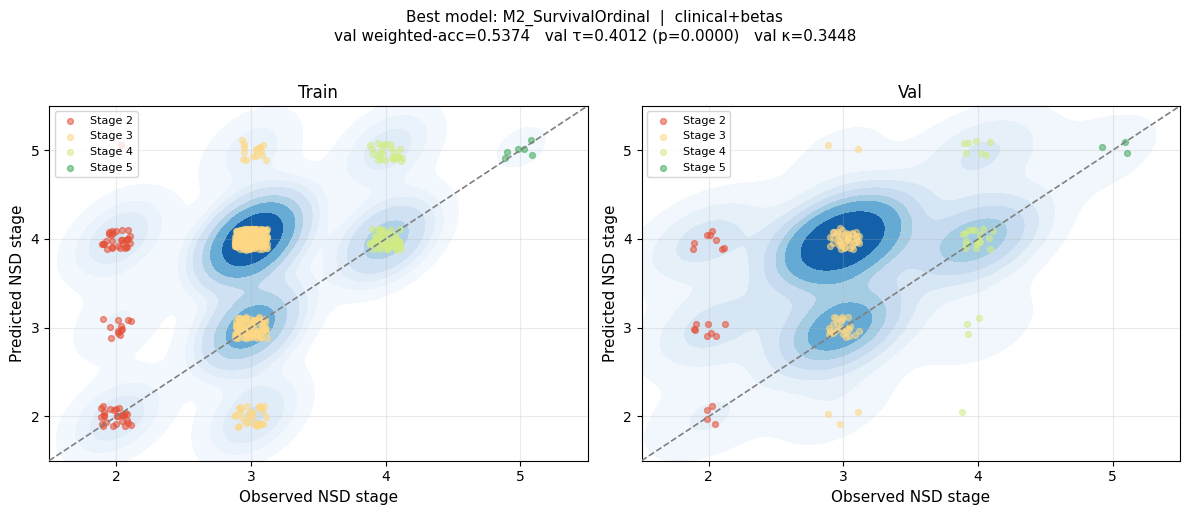

In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# BEST MODEL: refit, metrics, and KDE plot
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

best = all_results.loc[all_results["val_wacc"].idxmax()].copy()
print(f"★  Refitting best model: {best['model']}  |  {best['ablation']}  |  {best['hp']}")

feat_cols = ABLATIONS[best["ablation"]]
hp        = dict(item.split("=") for item in best["hp"].split(","))

# ── Reconstruct features & refit ──────────────────────────────────────────

if best["model"] == "M1_WeightedOrdinal":
    distr, method = best["hp"].split(",")
    y_tr     = ord_train_fe["NSD_ordered"].cat.remove_unused_categories()
    X_tr     = ord_train_fe[feat_cols].astype(float)
    y_v      = ord_val_fe["NSD_ordered"].cat.remove_unused_categories()
    X_v      = ord_val_fe[feat_cols].astype(float)
    pred_tr, pred_v = run_m1(y_tr, X_tr, y_v, X_v, distr, method)
    y_tr_num = y_tr.astype(float).to_numpy()
    y_v_num  = y_v.astype(float).to_numpy()

elif best["model"] == "M2_SurvivalOrdinal":
    feat_cols_m2 = [c for c in feat_cols if c != "time"]
    y_tr_num = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v_num  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    pred_tr, pred_v = run_m2(
        ord_train_fe, y_tr_num, ord_val_fe, y_v_num,
        feat_cols_m2,
        n_est=int(hp["n"]),
        lr=float(hp["lr"]),
        cal=hp["cal"] == "True",
    )

else:  # M3_GBTSurvival
    feat_cols_m3 = [c for c in feat_cols if c != "time"]
    y_tr_num = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v_num  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    pred_tr, pred_v = run_m3(
        ord_train_fe, y_tr_num, ord_val_fe, y_v_num,
        feat_cols_m3,
        max_iter=int(hp["n"]),
        lr=float(hp["lr"]),
        max_leaf=int(hp["leaf"]),
        l2=float(hp["l2"]),
    )

pred_tr = np.asarray(pred_tr, dtype=float)
pred_v  = np.asarray(pred_v,  dtype=float)

# ── Metrics printout ───────────────────────────────────────────────────────

tr_m = compute_metrics(y_tr_num, pred_tr, prefix="train_")
v_m  = compute_metrics(y_v_num,  pred_v,  prefix="val_")

labels = {
    "wacc":  "Weighted accuracy",
    "wmae":  "Weighted MAE",
    "tau":   "Kendall τ",
    "tau_p": "  τ p-value",
    "kappa": "Quadratic κ",
    "f1":    "Macro F1",
    "mae":   "MAE",
}
print(f"\n{'Metric':<22} {'Train':>10} {'Val':>10}")
print("─" * 44)
for key, label in labels.items():
    print(f"  {label:<20} {tr_m[f'train_{key}']:>10.4f} {v_m[f'val_{key}']:>10.4f}")

# Flag train/val gap
gap = tr_m["train_wacc"] - v_m["val_wacc"]
if gap > 0.15:
    print(f"\n  ⚠  Train/val wacc gap = {gap:.3f} — possible overfitting."
          f" Consider increasing l2_regularization or reducing max_leaf_nodes.")

print(f"\n  Features used: {feat_cols}")

# ── KDE plot ───────────────────────────────────────────────────────────────

stage_range = (1.5, 5.5)
jitter      = 0.12
rng         = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Best model: {best['model']}  |  {best['ablation']}\n"
    f"val weighted-acc={v_m['val_wacc']:.4f}   "
    f"val τ={v_m['val_tau']:.4f} (p={v_m['val_tau_p']:.4f})   "
    f"val κ={v_m['val_kappa']:.4f}",
    fontsize=11, y=1.02
)

for ax, y_true, y_pred, split in [
    (axes[0], y_tr_num, pred_tr, "Train"),
    (axes[1], y_v_num,  pred_v,  "Val"),
]:
    stages  = np.unique(y_true)
    palette = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(stages)))

    sns.kdeplot(
        x=y_true + rng.uniform(-jitter, jitter, len(y_true)),
        y=y_pred + rng.uniform(-jitter, jitter, len(y_pred)),
        fill=True, cmap="Blues", thresh=0.05, levels=8, ax=ax
    )
    for stage, col in zip(stages, palette):
        mask = y_true == stage
        ax.scatter(
            y_true[mask] + rng.uniform(-jitter, jitter, mask.sum()),
            y_pred[mask] + rng.uniform(-jitter, jitter, mask.sum()),
            color=col, alpha=0.55, s=18, label=f"Stage {int(stage)}", zorder=3
        )

    lo, hi = stage_range
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1.2, zorder=4)
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed NSD stage", fontsize=11)
    ax.set_ylabel("Predicted NSD stage", fontsize=11)
    ax.set_title(split, fontsize=12)
    ax.set_xticks(sorted(stages));  ax.set_yticks(sorted(stages))
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("best_model_kde.png", dpi=150, bbox_inches="tight")
plt.show()

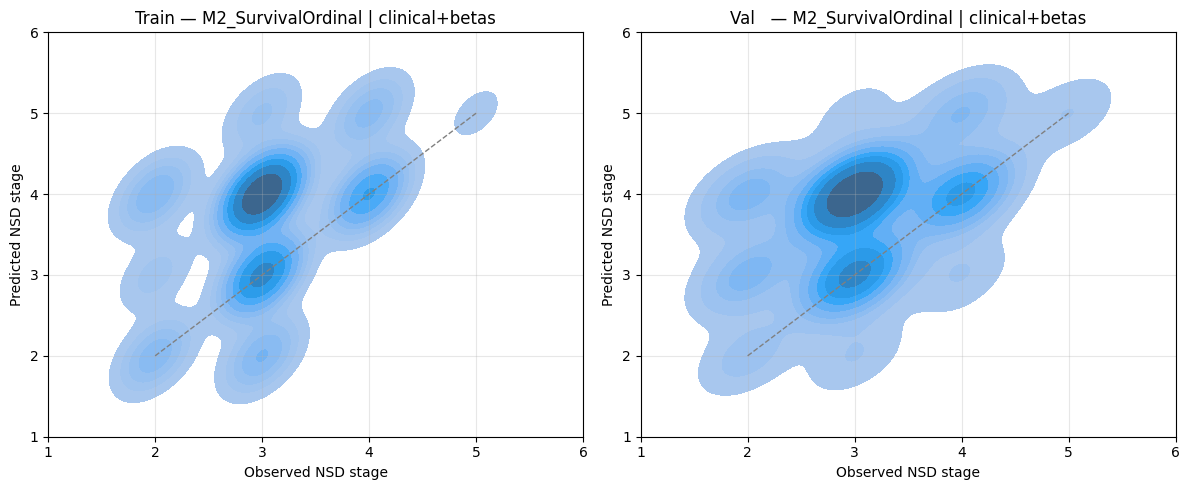

In [28]:
# ── Plain KDE plot ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in [
    (axes[0], y_tr_num, pred_tr, f"Train — {best['model']} | {best['ablation']}"),
    (axes[1], y_v_num,  pred_v,  f"Val   — {best['model']} | {best['ablation']}"),
]:
    sns.kdeplot(x=true.astype(float), y=pred.astype(float), fill=True, ax=ax)
    lo, hi = float(np.min(true)), float(np.max(true))
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1)
    ax.set_xlabel("Observed NSD stage")
    ax.set_ylabel("Predicted NSD stage")
    ax.set_xlim(1, 6)
    ax.set_ylim(1, 6)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("best_model_kde_plain.png", dpi=150, bbox_inches="tight")
plt.show()